<a href="https://colab.research.google.com/github/EdgarPrueba/Portafolio1/blob/main/NB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 1: Clasificación Automática de Modulaciones (AMC) mediante Aprendizaje Profundo

## 1. Configuración del entorno y preprocesamiento del dataset

En esta sección se establece la semilla aleatoria (`SEED = 42`) para garantizar la reproducibilidad de los experimentos. Posteriormente, se monta Google Drive y se carga el conjunto de datos **RadioML 2016.10a**.

Para mantener un tiempo de ejecución y un consumo de memoria razonables, se seleccionan cuatro esquemas de modulación representativos: **BPSK, QPSK, 8PSK y QAM16**. Además, se utilizan hasta **400 muestras por combinación de modulación y SNR**.

El conjunto resultante contiene muestras I/Q asociadas a diferentes niveles de SNR, lo que permite estudiar el efecto del ruido sobre la clasificación automática de modulaciones.

In [ ]:
# =============================================================
# CELL 1 — Descarga y preparación de RadioML 2016.10a
# =============================================================

import os
import tarfile
import pickle
import numpy as np
import torch

# -------------------------------------------------------------
# 1. Semilla
# -------------------------------------------------------------
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Semilla fijada en 42. Entorno PyTorch listo.")


# -------------------------------------------------------------
# 2. Configuración
# -------------------------------------------------------------
ARCHIVE_FILENAME = "RML2016.10a.tar.bz2"
DATASET_FILENAME = "RML2016.10a_dict_optimized.pkl"

DATASET_URL = (
    "https://zenodo.org/records/18397070/files/"
    "RML2016.10a.tar.bz2?download=1"
)


# -------------------------------------------------------------
# 3. Eliminar archivo incompleto
# -------------------------------------------------------------
if os.path.exists(ARCHIVE_FILENAME):

    file_size = os.path.getsize(ARCHIVE_FILENAME)

    if file_size < 100 * 1024 * 1024:
        print("\nArchivo comprimido incompleto detectado.")
        print("Eliminando descarga anterior...")
        os.remove(ARCHIVE_FILENAME)
        print("Archivo eliminado.")


# -------------------------------------------------------------
# 4. Descargar dataset
# -------------------------------------------------------------
if not os.path.exists(ARCHIVE_FILENAME):

    print("\nDescargando RadioML 2016.10a...")

    !curl -L --fail --retry 3 -o "{ARCHIVE_FILENAME}" "{DATASET_URL}"

    print("\nDescarga completada.")

else:

    print("\nArchivo comprimido válido ya disponible.")


# -------------------------------------------------------------
# 5. Verificar tamaño
# -------------------------------------------------------------
file_size = os.path.getsize(ARCHIVE_FILENAME)

print(
    f"Tamaño del archivo: "
    f"{file_size / (1024**2):.1f} MB"
)

if file_size < 100 * 1024 * 1024:

    raise RuntimeError(
        "La descarga está incompleta. "
        "El archivo descargado no parece ser válido."
    )


# -------------------------------------------------------------
# 6. Extraer dataset
# -------------------------------------------------------------
print("\nExtrayendo dataset...")

try:

    with tarfile.open(
        ARCHIVE_FILENAME,
        "r:bz2"
    ) as tar:

        tar.extractall(".")

except (tarfile.ReadError, OSError) as e:

    raise RuntimeError(
        "El archivo descargado no es un TAR.BZ2 válido. "
        "Elimine el archivo y vuelva a ejecutar la celda."
    ) from e

print("Extracción completada.")


# -------------------------------------------------------------
# 7. Buscar el archivo optimizado
# -------------------------------------------------------------
DATASET_PATH = None

for root, _, files in os.walk("."):

    if DATASET_FILENAME in files:

        DATASET_PATH = os.path.join(
            root,
            DATASET_FILENAME
        )

        break


if DATASET_PATH is None:

    raise FileNotFoundError(
        f"No se encontró {DATASET_FILENAME} "
        "después de extraer el dataset."
    )

print(
    f"Dataset encontrado: {DATASET_PATH}"
)


# -------------------------------------------------------------
# 8. Cargar dataset
# -------------------------------------------------------------
print("\nCargando dataset...")

with open(DATASET_PATH, "rb") as f:

    RMLData = pickle.load(
        f,
        encoding="latin1"
    )

print("Dataset cargado correctamente.")


# -------------------------------------------------------------
# 9. Eliminar archivo comprimido
# -------------------------------------------------------------
if os.path.exists(ARCHIVE_FILENAME):

    os.remove(ARCHIVE_FILENAME)

    print("Archivo comprimido eliminado para liberar espacio.")


# -------------------------------------------------------------
# 10. Seleccionar modulaciones
# -------------------------------------------------------------
TARGET_MODS = [
    "BPSK",
    "QPSK",
    "8PSK",
    "QAM16"
]

SAMPLES_PER_SNR_MOD = 400

X_list = []
y_list = []
snr_list = []

mod_to_idx = {
    mod: i
    for i, mod in enumerate(TARGET_MODS)
}


for (mod, snr), samples in RMLData.items():

    mod_str = (
        mod.decode("utf-8")
        if isinstance(mod, bytes)
        else str(mod)
    )

    if mod_str in TARGET_MODS:

        n_take = min(
            samples.shape[0],
            SAMPLES_PER_SNR_MOD
        )

        X_list.append(
            samples[:n_take]
        )

        y_list.extend(
            [mod_to_idx[mod_str]] * n_take
        )

        snr_list.extend(
            [snr] * n_take
        )


# -------------------------------------------------------------
# 11. Construir dataset final
# -------------------------------------------------------------
X = np.vstack(X_list)

y = np.array(y_list)

snrs = np.array(snr_list)


# -------------------------------------------------------------
# 12. Resumen
# -------------------------------------------------------------
print("\n--- RESUMEN DEL DATASET ---")

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Modulaciones: {TARGET_MODS}")
print(f"SNRs: {np.unique(snrs)} dB")
print(f"Muestras totales: {len(X)}")

Semilla fijada en 42. Entorno PyTorch listo.

Archivo comprimido válido ya disponible.
Tamaño del archivo: 202.8 MB

Extrayendo dataset...


/tmp/ipykernel_4672/3360093681.py:97: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


Extracción completada.
Dataset encontrado: ./RML2016.10a_dict_optimized.pkl

Cargando dataset...
Dataset cargado correctamente.
Archivo comprimido eliminado para liberar espacio.

--- RESUMEN DEL DATASET ---
Forma de X: (32000, 2, 128)
Forma de y: (32000,)
Modulaciones: ['BPSK', 'QPSK', '8PSK', 'QAM16']
SNRs: [-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18] dB
Muestras totales: 32000


## 2. Vectorización de características y modelos de clasificación

Cada muestra del conjunto de datos está representada por sus componentes en fase y cuadratura (**I/Q**) con dimensión `(2, 128)`. Para utilizar estas muestras como entrada de los clasificadores, ambas componentes se aplanan en un vector de **256 características**:

\[
2 \times 128 = 256
\]

El conjunto de datos se divide en **80 % para entrenamiento y 20 % para prueba**, manteniendo la información de SNR de cada muestra para realizar posteriormente la evaluación por nivel de ruido.

Se comparan dos modelos:

1. **Regresión Logística Multinomial:** utilizada como línea base clásica.
2. **Perceptrón Multicapa (MLP):** modelo de aprendizaje profundo implementado en PyTorch, con arquitectura:

\[
256 \rightarrow 64 \rightarrow 4
\]

donde las cuatro salidas corresponden a las cuatro clases de modulación seleccionadas.

Antes del entrenamiento, las características se normalizan utilizando únicamente los datos de entrenamiento para evitar fuga de información (*data leakage*).

In [ ]:
# ==========================================
# CELDA 2: Preprocesamiento y modelos
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import torch.nn as nn

# 1. Convertir cada muestra I/Q (2, 128) en un vector de 256 características
X_flat = X.reshape(X.shape[0], -1).astype(np.float32)

print(f"Características por muestra: {X_flat.shape[1]}")

# 2. División entrenamiento/prueba
# También conservamos el SNR de cada muestra
X_train, X_test, y_train, y_test, snrs_train, snrs_test = train_test_split(
    X_flat,
    y,
    snrs,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

# Verificar que todos los SNR están representados en test
print(f"SNRs en test:  {np.unique(snrs_test)} dB")

# 3. Normalización
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Línea base: Regresión Logística multinomial
logistic_model = LogisticRegression(
    max_iter=300,
    random_state=SEED
)

# 5. Modelo MLP pequeño
class MLP(nn.Module):
    def __init__(self, input_size=256, hidden_size=64, num_classes=4):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        return self.network(x)

mlp_model = MLP()

print("\nModelos definidos:")
print("- Regresión Logística multinomial")
print("- MLP: 256 → 64 → 4")

Características por muestra: 256
Entrenamiento: 25600 muestras
Prueba:        6400 muestras
SNRs en test:  [-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18] dB

Modelos definidos:
- Regresión Logística multinomial
- MLP: 256 → 64 → 4


## 3. Entrenamiento y optimización

La Regresión Logística se ajusta utilizando las muestras de entrenamiento normalizadas. El MLP se entrena durante **10 épocas** mediante el optimizador **Adam**, con una tasa de aprendizaje de:

\[
\eta = 0.001
\]

La función de pérdida utilizada para el MLP es la entropía cruzada (`CrossEntropyLoss`), adecuada para un problema de clasificación multiclase.

Como evaluación inicial, se calcula la **Accuracy general** sobre el conjunto de prueba para ambos modelos.

In [ ]:
# ==========================================
# CELDA 3: Entrenamiento y evaluación
# ==========================================
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score

# 1. Preparar datos para PyTorch
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

# ==========================================
# 2. Regresión Logística
# ==========================================
print("Entrenando Regresión Logística...")

logistic_model.fit(X_train_scaled, y_train)

print("Regresión Logística entrenada.")

# ==========================================
# 3. MLP
# ==========================================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    mlp_model.parameters(),
    lr=0.001
)

epochs = 10

print(f"\nEntrenando MLP ({epochs} épocas)...")

mlp_model.train()

for epoch in range(epochs):

    running_loss = 0.0

    for inputs, labels in train_loader:

        optimizer.zero_grad()

        outputs = mlp_model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Época {epoch + 1:02d}/{epochs} "
        f"- Loss: {epoch_loss:.4f}"
    )

print("\nEntrenamiento completado.")

# ==========================================
# 4. Evaluación general sobre test
# ==========================================

# Regresión Logística
y_pred_logistic = logistic_model.predict(X_test_scaled)

accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

# MLP
mlp_model.eval()

with torch.no_grad():
    X_test_t = torch.tensor(
        X_test_scaled,
        dtype=torch.float32
    )

    outputs = mlp_model(X_test_t)
    y_pred_mlp = torch.argmax(
        outputs,
        dim=1
    ).numpy()

accuracy_mlp = accuracy_score(
    y_test,
    y_pred_mlp
)

print("\n--- ACCURACY GENERAL ---")
print(f"Regresión Logística: {accuracy_logistic:.4f}")
print(f"MLP:                 {accuracy_mlp:.4f}")

Entrenando Regresión Logística...
Regresión Logística entrenada.

Entrenando MLP (10 épocas)...
Época 01/10 - Loss: 1.3879
Época 02/10 - Loss: 1.3464
Época 03/10 - Loss: 1.3175
Época 04/10 - Loss: 1.2924
Época 05/10 - Loss: 1.2710
Época 06/10 - Loss: 1.2490
Época 07/10 - Loss: 1.2310
Época 08/10 - Loss: 1.2108
Época 09/10 - Loss: 1.1908
Época 10/10 - Loss: 1.1730

Entrenamiento completado.

--- ACCURACY GENERAL ---
Regresión Logística: 0.2492
MLP:                 0.3267


## 4. Evaluación del desempeño en función del SNR

Para analizar el efecto del nivel de ruido sobre la clasificación, se calcula la **Accuracy de cada modelo para cada nivel de SNR**, desde \(-20\) dB hasta \(+18\) dB.

La comparación entre la Regresión Logística y el MLP permite determinar cómo cambia el desempeño de los clasificadores conforme aumenta la relación señal a ruido.

### Figura 1. Accuracy vs. SNR

La primera figura muestra la Accuracy obtenida por ambos modelos en función del SNR. También se incluye una referencia del **25 %**, correspondiente al desempeño esperado de una clasificación aleatoria entre cuatro clases.

Esta gráfica constituye el resultado principal del experimento, ya que permite observar directamente la relación entre la calidad de la señal y la capacidad de los modelos para identificar correctamente la modulación.

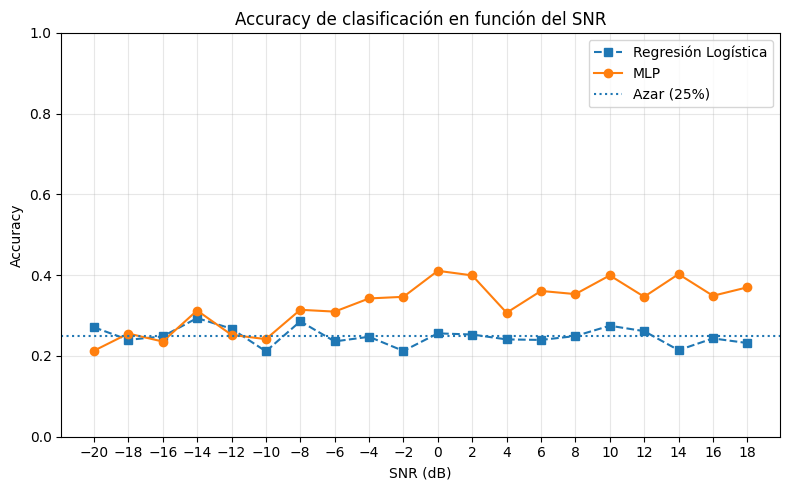

In [ ]:
# ==========================================
# CELDA 4: Evaluación por SNR
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Obtener predicciones sobre todo el conjunto de prueba

# Regresión Logística
y_pred_logistic = logistic_model.predict(X_test_scaled)

# MLP
mlp_model.eval()

with torch.no_grad():
    X_test_t = torch.tensor(
        X_test_scaled,
        dtype=torch.float32
    )

    outputs = mlp_model(X_test_t)

    y_pred_mlp = torch.argmax(
        outputs,
        dim=1
    ).numpy()

# 2. Calcular Accuracy para cada nivel de SNR
snr_unique = np.sort(np.unique(snrs_test))

acc_logistic_snr = []
acc_mlp_snr = []

for snr in snr_unique:

    mask = snrs_test == snr

    acc_logistic = accuracy_score(
        y_test[mask],
        y_pred_logistic[mask]
    )

    acc_mlp = accuracy_score(
        y_test[mask],
        y_pred_mlp[mask]
    )

    acc_logistic_snr.append(acc_logistic)
    acc_mlp_snr.append(acc_mlp)

# 3. Gráfica principal
plt.figure(figsize=(8, 5))

plt.plot(
    snr_unique,
    acc_logistic_snr,
    's--',
    label='Regresión Logística'
)

plt.plot(
    snr_unique,
    acc_mlp_snr,
    'o-',
    label='MLP'
)

# Referencia de clasificación aleatoria
plt.axhline(
    0.25,
    linestyle=':',
    label='Azar (25%)'
)

plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('Accuracy de clasificación en función del SNR')

plt.xticks(snr_unique)
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 5. Análisis de errores del clasificador

Finalmente, se analiza el comportamiento del MLP mediante una **matriz de confusión para SNR = 10 dB**.

La matriz permite identificar qué esquemas de modulación son correctamente clasificados y cuáles presentan mayor confusión entre sí. De esta manera, se complementa el análisis global de Accuracy con una evaluación específica de los errores del clasificador.

### Figura 2. Matriz de confusión del MLP a 10 dB

La matriz de confusión muestra la distribución de las predicciones del MLP para las cuatro clases de modulación seleccionadas a un SNR de 10 dB.

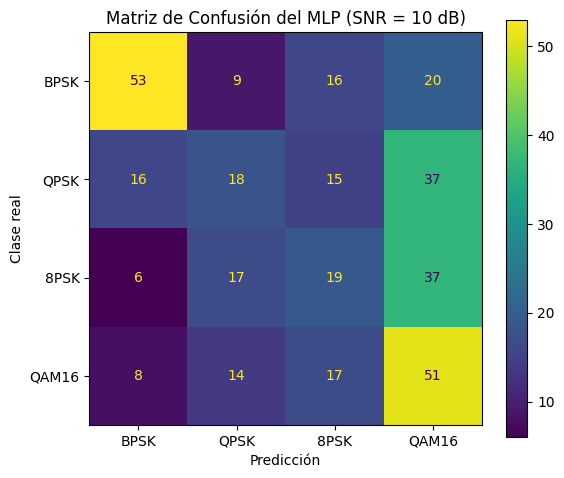

In [ ]:
# ==========================================
# CELDA 5: Matriz de Confusión del MLP
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# SNR seleccionado para analizar los errores
snr_target = 10

# Seleccionar muestras del conjunto de prueba
mask = snrs_test == snr_target

# Matriz de confusión
cm = confusion_matrix(
    y_test[mask],
    y_pred_mlp[mask]
)

# Visualización
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=TARGET_MODS
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)

plt.title(f'Matriz de Confusión del MLP (SNR = {snr_target} dB)')
plt.xlabel('Predicción')
plt.ylabel('Clase real')
plt.tight_layout()
plt.show()